# Full LOB from Strategic Primitives — Bertrand–Ma–Noh MFG, Fixed Framework

Code-only notebook. Companion to the LaTeX report.

## What was broken, and what this version fixes

**Issue 1 — the spread pinned mechanically at the no-arbitrage floor (even with $f>0$).**
Two root causes, both economic, both fixed:

1. **The LP population violated the model's own classification rule (§3.4 of the report).**
   Traders with $v \le b_{\text{best}}$ should market-sell, yet the old code let LPs with
   $v \approx 0$ post asks. A seller who values the asset at $0.05$ happily quotes at any
   $a > 0.05$, so Bertrand competition slammed the touch into the grid floor at $p$ — the
   "floor binds" outcome was a grid artifact, not an equilibrium. **Fix:** ask-side LPs are
   restricted to $v \in (b_{\text{best}}, p)$ and bid-side LPs to $v \in (p, a_{\text{best}})$.
   Because each side's marginal LP is defined by the *other* side's touch, the two touches
   become a **joint fixed point across both sides** — a coupling the old one-side-at-a-time
   code could not represent.

2. **Quoting at the touch was costless.** The fee alone yields spread $\approx p\,f/(1-f)$,
   and nothing at $f=0$. **Fix:** Glosten–Milgrom adverse selection. A share $\eta$ of order
   flow is informed (knows the resolution). The probability a fill at ask $a$ is informed is
   $$\chi(a) = \frac{\eta\,p}{\eta\,p + (1-\eta)\,(1-F(a))},$$
   and the per-fill margin becomes
   $$m(a,v) = a(1-f) - \big[(1-\chi(a))\,v + \chi(a)\cdot 1\big].$$
   Even a dogmatic LP (who keeps prior $v$) rationally concedes that a fill from an informed
   buyer means the contract pays 1. The marginal LP's break-even ask then sits **strictly above
   the bid even at $f=0$**, so the spread is positive, endogenous, and increasing in both
   $\eta$ and $f$ — on top of a third component the fixed framework reveals: with convex
   replenishment costs and finite capacity, undercutting is replenishment-bottlenecked, so
   Bertrand competition is effectively capacity-constrained (Edgeworth) and a rent keeps the
   spread positive even at $\eta=f=0$ (§9). The GM channel is exactly the extension flagged in the report's conclusion, now
   inside the model rather than outside it.

**Issue 2 — no proper convergence (Cesàro averaging was masking a permanent limit cycle).**
Bertrand best responses on a discrete price grid are integer-valued, so the outer map cycled
between adjacent grid points forever. **Fixes:**

- **Continuous ask choice**: coarse grid scan + bounded Brent refinement on interpolated fill
  rates, so the best-response map is continuous and damped Picard can genuinely converge.
- **Quantile middle loop run to tolerance** (sup-norm on the depth grid), replacing the fixed
  3/5 "smoother" steps.
- **Exact stationary distributions** by direct linear solve of $m^\top Q = 0$, replacing
  80,000 power iterations (also a ~100× speedup).
- **Residual-based stopping**: the loop declares convergence only when the undamped Picard
  residual $\|\Phi(D)-D\|_\infty / \|D\|_\infty$ and the touch movement fall below tolerance.
  No Cesàro mean, no fixed iteration count, and the residual history is reported and plotted.

**A third bug found while fixing the first two — the no-liquidity trap.** With the corrected
LP population, margins are thin ($\sim$ a few cents). The old replenishment cost $\kappa=0.4$
made the cost per unit posted ($\approx \kappa l / 2\Psi \approx 0.5$) exceed the margin, so the
unique reachable equilibrium had an **empty book** ($\bar d = 0$, $\mathcal D \equiv 0$) and the
"touch" was set by where depth happened to vanish. $\kappa$ is recalibrated to the corrected
margin scale ($\kappa = 0.05$, $\bar\ell = 4$), restoring an interior equilibrium where depth
self-balances: $\mathcal D$ adjusts until the per-unit fill rate $\mu = \phi/\mathcal D$ is
commensurate with optimal replenishment.

**A fourth fix — fill rates now respect price priority.** The old spec
$\mu_0(a)=\phi(a)/\mathcal D(a)$ diluted an order only by the *local density*, so an LP
posting behind the depth wall at an empty far price captured flow as if buyers teleported
past better quotes — creating a built-in oscillator (depth appears, fill rates collapse,
depth leaves) and a dimensional inconsistency (flow divided by a density). Now a unit at
price $a$ is diluted by **all depth at-or-better prices**:
$$\mu(a) = \frac{\phi(a)}{\max\{\mathcal D_{\mathrm{cum}}(a),\ \mathcal D_{\mathrm{own}}\}},
\qquad \mathcal D_{\mathrm{cum}}(a) = \int_{a_{\mathrm{lo}}}^{a} d(s)\,ds,$$
which preserves the undercutting incentive at the touch (a lone deviator is diluted only by
its own queue $\mathcal D_{\mathrm{own}}$) and removes the teleporting-buyer arbitrage.

**A fifth fix — the moving quantile grid collapsed; the state space is now the physical
inventory lattice.** With $\delta_s=\delta_b=1$ the queue lives on the integers
$\{0,1,\dots,q_{\max}\}$. The old implementation deformed the state grid toward the
quantiles of the stationary law each middle-loop pass; at high fill rates the mass
concentrates at $q=0$, the grid collapsed to all-zeros, jump destinations degenerated, and
the HJB spuriously returned $V_0\approx 0$ for aggressive quotes — silently inflating the
spread and deepening the no-liquidity trap. The state grid is now **fixed at the lattice**
and the middle loop iterates the **rank profile** $u_n$ (the only channel through which the
distribution enters the HJB), run to tolerance with damping. This is exact, collapse-proof,
and faster.

Smaller fixes: equal-mass quantile cells for both $F(v)$ and $G(r)$ (replacing pdf×trapezoid
weights), the best ask defined as $\min_{k,l} a^*_{k,l}$ over active types (replacing the
5%-of-max-depth threshold trick), a no-crossing guard $a \ge b_{\text{best}} + \text{tick}$,
participation: types whose best $V_0 \le 0$ exit (adverse selection shuts down marginal LPs —
the limits-to-arbitrage channel of the report's Strand 3), adaptive relaxation damping
(shrink $\omega$ on residual growth, recover on decay), and the depth residual measured in
$L^1$ (the sup-norm is hypersensitive to kernel jitter from within-cell dispersion).

## 1. Imports

In [1]:
import numpy as np
from scipy.stats import beta as beta_dist
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
import time

if not hasattr(np, "trapz"):           # NumPy 2.x shim
    np.trapz = np.trapezoid

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 12, 'axes.labelsize': 14,
    'axes.titlesize': 14, 'legend.fontsize': 11, 'lines.linewidth': 2,
    'figure.dpi': 110,
})

## 2. Ma–Noh primitives (vectorized, exact)

- `solve_hjb`: policy iteration on the stationary HJB. Matrix build is vectorized with
  `np.subtract.at`. No $V_0$ normalisation — $A$ is strictly diagonally dominant with excess
  $\rho > 0$, so the system is well-posed as is.
- `stat_dist`: stationary law of the controlled CTMC by **direct linear solve** of
  $m^\top Q = 0$, $\sum_n m_n = 1$ (replaces 80,000 power iterations; exact and ~100× faster).
- The inventory state space is the **physical lattice** $q_n = n\,\delta$,
  $n = 0,\dots,q_{\max}$ (fixed; jump destinations are exact index shifts). The middle loop
  iterates the rank profile $u_n$ on this lattice.

In [2]:
def rank_grid(N):
    return (np.arange(1, N + 1) - 0.5) / N

def solve_hjb(q, u, jp, jm, rho, kappa, l_bar, psi, theta, margin, db,
              mu_exec, max_iter=120, tol=1e-10):
    """Policy iteration on the stationary HJB (no V0 normalisation)."""
    N = len(q)
    Psi = 1.0 + psi * u
    Theta = 1.0 + theta * (1.0 - u)
    lb = mu_exec * Theta                      # execution intensity (policy-independent)
    pi = margin * lb * db * (q > 0)           # per-state flow profit
    idx = np.arange(N)
    l = np.zeros(N); V = np.zeros(N)
    for _ in range(max_iter):
        ls = l * Psi
        A = np.zeros((N, N))
        A[idx, idx] = rho + ls + lb
        np.subtract.at(A, (idx, jp), ls)
        np.subtract.at(A, (idx, jm), lb)
        b = pi - 0.5 * kappa * l * l
        try:
            Vn = np.linalg.solve(A, b)
        except np.linalg.LinAlgError:
            break
        ln = np.clip((Psi / kappa) * (Vn[jp] - Vn), 0.0, l_bar)
        done = np.max(np.abs(ln - l)) < tol
        V, l = Vn, ln
        if done:
            break
    return V, l

def stat_dist(jp, jm, lp, lm):
    """Stationary law of the CTMC: direct solve of m^T Q = 0, sum m = 1."""
    N = len(lp)
    idx = np.arange(N)
    Q = np.zeros((N, N))
    np.add.at(Q, (idx, jp), lp)
    np.add.at(Q, (idx, jm), lm)
    Q[idx, idx] -= (lp + lm)
    A = Q.T.copy()
    A[-1, :] = 1.0
    b = np.zeros(N); b[-1] = 1.0
    try:
        m = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        m, *_ = np.linalg.lstsq(A, b, rcond=None)
    m = np.maximum(m, 0.0)
    s = m.sum()
    return m / s if s > 0 else np.ones(N) / N

## 3. Parameters

$\kappa$ is recalibrated to the corrected margin scale (see header). $\eta$ is the informed
share; $f$ the proportional fee. Setting $\eta = f = 0$ recovers the frictionless limit
(spread $\to$ 0, demonstrated in §9).

In [3]:
p_mid = 0.65          # fundamental / classification cutoff
fee   = 0.01          # proportional transaction fee  (Polymarket-like)
eta   = 0.05          # informed share of order flow  (Glosten-Milgrom channel)

alpha_F, beta_F = 6.5, 3.5    # buyer/LP valuation law F = Beta(alpha_F, beta_F)
lam_arr  = 10.0               # Poisson arrival rate
N_total  = 100.0              # trader mass
r_min, r_max = 0.05, 2.0      # discount-rate support (G uniform-in-log cells)

delta_s = delta_b = 1.0
kappa, l_bar = 0.05, 4.0      # RECALIBRATED: old kappa=0.4 emptied the book (see header)
psi, theta   = 0.3, 0.7       # rank couplings

N_v, N_r, N_a, N_q = 8, 5, 18, 21   # N_q = inventory lattice states {0,...,q_max}
q_max        = 20.0
sigma_smooth = 0.018          # within-cell dispersion kernel for aggregation
D_own        = 0.30           # deviator's own depth (price-priority dilution floor)
tick         = 0.002          # no-crossing guard

omega_D, omega_t = 0.20, 0.25 # base Picard damping (adaptive at runtime)
outer_max  = 85
tol_D      = 0.05             # undamped L1 Picard residual tolerance on D
tol_touch  = 2.5e-4            # on damped-touch movement (Cauchy)             # touch movement tolerance

# equal-mass log-midpoint cells for G(r)
r_grid = r_min * (r_max / r_min) ** ((np.arange(N_r) + 0.5) / N_r)
w_r    = np.ones(N_r) / N_r

## 4. Side economics: adverse selection, order flow, margins

Each side is solved in its own "ask coordinates" (the NO side is the YES bid reflected,
$b = 1 - a_{NO}$, with Beta parameters swapped). For a side with fundamental $p_s$ and
valuation law $F$:

- informed fill share $\chi(a) = \dfrac{\eta p_s}{\eta p_s + (1-\eta)(1 - F(a))}$ — rises
  deeper in the book, where uninformed flow thins out (stale-quote risk);
- buy flow $\phi(a) = \lambda\big[(1-\eta)(1-F(a)) + \eta p_s\big]$;
- per-fill margin $m(a,v) = a(1-f) - \big[(1-\chi(a))v + \chi(a)\big]$.

`build_v_grid` places the LP types as **equal-mass Beta-quantile cells on the
classification-consistent window** $(b_{\text{best}}, p_s)$.

In [4]:
def side_funcs(p_side, a_b, b_b):
    """Economics of one side. F = Beta(a_b, b_b) in this side's coordinates."""
    F  = lambda x: beta_dist.cdf(x, a_b, b_b)
    Fi = lambda u: beta_dist.ppf(u, a_b, b_b)
    def chi(a):                       # prob a fill at ask a is informed
        inf_flow = eta * p_side
        uninf    = (1 - eta) * (1.0 - F(a))
        return inf_flow / (inf_flow + uninf + 1e-300)
    def phi(a):                       # buy flow hitting ask a
        return lam_arr * ((1 - eta) * (1.0 - F(a)) + eta * p_side)
    def m_eff(a, v):                  # margin per fill net of fee + adverse selection
        c = chi(a)
        return a * (1 - fee) - ((1 - c) * v + c * 1.0)
    return F, Fi, chi, phi, m_eff

def build_v_grid(Fi, F, lo, hi, N):
    """Equal-mass Beta-quantile cells on (lo, hi): classification-consistent LPs."""
    Plo, Phi = F(lo), F(hi)
    if Phi - Plo < 1e-6:
        return np.full(N, 0.5 * (lo + hi)), np.zeros(N)
    probs = Plo + (Phi - Plo) * (np.arange(N) + 0.5) / N
    v = np.clip(Fi(probs), lo + 1e-4, hi - 1e-4)
    mass = np.full(N, (Phi - Plo) / N)
    return v, mass

## 5. Type-level problem: HJB + KFE to tolerance, continuous ask choice

`solve_type_at_ask` runs the quantile fixed point **to tolerance** (not a fixed count).
`best_response` scans the admissible grid, then refines the optimum with bounded Brent on
the interpolated fill-rate curve — making the Bertrand best response **continuous in the
aggregate state**, which is what kills the grid limit cycle.

In [5]:
# Physical inventory lattice (delta_s = delta_b = 1): fixed state grid,
# exact jump destinations. The middle loop iterates the RANK profile u_n.
Q_LAT  = np.arange(N_q) * delta_s
JP_LAT = np.minimum(np.arange(N_q) + 1, N_q - 1)
JM_LAT = np.maximum(np.arange(N_q) - 1, 0)

def solve_type_at_ask(margin, rho, mu, u_init=None,
                      mid_max=60, mid_tol=1e-7, omega_mid=0.5):
    """HJB + KFE on the lattice; rank profile iterated to tolerance.
    Returns (V0, dbar, u)."""
    if margin <= 5e-4:
        return -np.inf, 0.0, u_init
    q, jp, jm = Q_LAT, JP_LAT, JM_LAT
    u = rank_grid(N_q) if u_init is None else u_init.copy()
    V = np.zeros(N_q); m = np.ones(N_q) / N_q
    for _ in range(mid_max):
        V, l = solve_hjb(q, u, jp, jm, rho=rho, kappa=kappa, l_bar=l_bar,
                         psi=psi, theta=theta, margin=margin, db=delta_b,
                         mu_exec=mu)
        Psi = 1 + psi * u; Theta = 1 + theta * (1 - u)
        m = stat_dist(jp, jm, l * Psi, mu * Theta)
        M = np.cumsum(m)
        u_new = M - 0.5 * m                  # midpoint rank of each lattice state
        un = (1 - omega_mid) * u + omega_mid * u_new
        diff = np.max(np.abs(un - u)); u = un
        if diff < mid_tol:
            break
    return float(V[0]), float(np.dot(m, q)), u

def best_response(v, rho, a_grid, mu_interp, m_eff, a_lo, a_hi, refine=True):
    """Coarse grid scan + bounded Brent refinement => continuous a*(v, r)."""
    best = (-np.inf, 0.0, None)
    u_ws = None
    for a in a_grid:
        if a < a_lo or a > a_hi:
            continue
        mg = m_eff(a, v)
        if mg <= 5e-4:
            continue
        V0, db, u_ws = solve_type_at_ask(mg, rho, mu_interp(a), u_init=u_ws)
        if V0 > best[0]:
            best = (V0, db, a)
    if best[2] is None:
        return -np.inf, 0.0, np.nan          # inactive type (exits)
    if not refine:
        return best
    j = int(np.argmin(np.abs(a_grid - best[2])))
    lo = max(a_lo, a_grid[max(j - 1, 0)])
    hi = min(a_hi, a_grid[min(j + 1, len(a_grid) - 1)])
    if hi - lo < 1e-5:
        return best
    cache = {}
    def negV0(a):
        a = float(a)
        if a in cache:
            return cache[a]
        mg = m_eff(a, v)
        if mg <= 5e-4:
            cache[a] = 1e6; return 1e6
        V0, db, _ = solve_type_at_ask(mg, rho, mu_interp(a), u_init=u_ws)
        cache[a] = -V0
        cache[(a, 'db')] = db
        return -V0
    res = minimize_scalar(negV0, bounds=(lo, hi), method='bounded',
                          options={'xatol': 1e-4, 'maxiter': 10})
    if -res.fun > best[0]:
        a_star = float(res.x)
        return -res.fun, cache.get((a_star, 'db'), best[1]), a_star
    return best

## 6. One Picard step for one side

Given the current depth $\mathcal D$ and the opposite touch (the no-crossing floor),
sweep all types' best responses, aggregate, and return the new depth and new touch
$a_{\text{best}} = \min_{k,l}\, a^*_{k,l}$ over **active** types ($V_0 > 0$) — no
depth-threshold tricks.

In [6]:
def make_a_grid(p_side):
    lo = max(0.05, p_side - 0.22)
    knee = min(p_side + 0.10, 0.90)
    g1 = np.linspace(lo, knee, 11)
    g2 = knee + (0.995 - knee) * (np.linspace(0, 1, 9)[1:] ** 1.6)
    return np.concatenate([g1, g2])

def side_step(p_side, aF, bF, D, a_grid, opp_touch, refine):
    """One best-response sweep for one side. Returns (D_new, a_best_new, tables)."""
    F, Fi, chi, phi, m_eff = side_funcs(p_side, aF, bF)
    v_grid, v_mass = build_v_grid(Fi, F, opp_touch, p_side, N_v)

    # PRICE PRIORITY: a unit at price a is diluted by all depth at-or-better
    # prices (buyers walk the book), not only by the local density.
    Dc = np.maximum(D, 0.0)
    D_cum = np.concatenate([[0.0], np.cumsum(0.5 * (Dc[1:] + Dc[:-1])
                                             * np.diff(a_grid))])
    mu_grid = phi(a_grid) / np.maximum(D_cum, D_own)
    mu_interp = lambda a: np.interp(a, a_grid, mu_grid)

    a_lo, a_hi = opp_touch + tick, a_grid[-1]
    a_star = np.full((N_v, N_r), np.nan)
    d_bar  = np.zeros((N_v, N_r))
    V0t    = np.full((N_v, N_r), -np.inf)
    for kv in range(N_v):
        for kr in range(N_r):
            V0, db, a = best_response(v_grid[kv], r_grid[kr], a_grid,
                                      mu_interp, m_eff, a_lo, a_hi, refine)
            a_star[kv, kr] = a; d_bar[kv, kr] = db; V0t[kv, kr] = V0

    # aggregate (Gaussian kernel = within-cell type dispersion)
    step = np.diff(a_grid)
    step_at = np.concatenate([[step[0]], (step[:-1] + step[1:]) / 2, [step[-1]]])
    D_new = np.zeros_like(a_grid)
    for kv in range(N_v):
        for kr in range(N_r):
            if not np.isfinite(a_star[kv, kr]) or V0t[kv, kr] <= 1e-9:
                continue
            w = N_total * v_mass[kv] * w_r[kr] * d_bar[kv, kr]
            kern = np.exp(-0.5 * ((a_grid - a_star[kv, kr]) / sigma_smooth) ** 2)
            D_new += w * kern / (np.sum(kern * step_at) + 1e-300)

    active = np.isfinite(a_star) & (V0t > 1e-9)
    # if the LP window has collapsed (frictionless limit), keep the touch put
    a_best_new = np.min(a_star[active]) if active.any() else np.nan
    return D_new, a_best_new, dict(a_star=a_star, d_bar=d_bar, V0=V0t,
                                   v_grid=v_grid, v_mass=v_mass,
                                   mu=mu_grid, active=active, chi=chi,
                                   phi=phi, m_eff=m_eff)

## 7. Joint two-sided equilibrium loop

State: $(\mathcal D_{YES}, \mathcal D_{NO}, a^{YES}_{\text{best}}, a^{NO}_{\text{best}})$,
updated Jacobi-style with damping. The spread is
$s = a^{YES}_{\text{best}} + a^{NO}_{\text{best}} - 1$. Convergence is declared on the
**undamped** Picard residual and touch movement; the full residual history is returned.

In [7]:
def run_equilibrium(eta_val, fee_val, label, outer=outer_max, verbose=True):
    global eta, fee
    eta, fee = eta_val, fee_val
    pY, pN = p_mid, 1 - p_mid
    gY, gN = make_a_grid(pY), make_a_grid(pN)
    DY = np.ones_like(gY) * 2.0
    DN = np.ones_like(gN) * 2.0
    aY, aN = pY + 0.06, pN + 0.06          # initial touches (YES ask, NO ask)
    hist = dict(resD=[], resT=[], ask=[], bid=[], spread=[])
    t0 = time.time(); converged = False
    wD, wT = omega_D, omega_t               # adaptive relaxation state
    res_prev = resT_prev = np.inf
    aY_prev, aN_prev = aY, aN
    n_ok = 0
    for it in range(outer):
        refine = it >= 6                    # grid-only warmup, then continuous a*
        bY, bN = 1 - aN, 1 - aY
        DYn, aYn, tabY = side_step(pY, alpha_F, beta_F, DY, gY, bY, refine)
        DNn, aNn, tabN = side_step(pN, beta_F, alpha_F, DN, gN, bN, refine)

        # undamped Picard residuals: L1 on depth, absolute on touches
        resD = max(np.sum(np.abs(DYn - DY)) / max(np.sum(DY), 1e-9),
                   np.sum(np.abs(DNn - DN)) / max(np.sum(DN), 1e-9))
        if np.isnan(aYn): aYn = aY          # collapsed window: touch unchanged
        if np.isnan(aNn): aNn = aN
        resT = abs(aYn - aY) + abs(aNn - aN)

        # adaptive relaxation, decoupled: wD tracks depth residual, wT tracks
        # touch residual (so depth noise cannot throttle touch convergence)
        if it >= 6:
            if resD > res_prev * 1.02:
                wD = max(wD * 0.6, 0.03)
            elif resD < res_prev:
                wD = min(wD * 1.05, omega_D)
            if resT > resT_prev * 1.02:
                wT = max(wT * 0.6, 0.05)
            elif resT < resT_prev:
                wT = min(wT * 1.05, omega_t)
        res_prev, resT_prev = resD, resT

        DY = (1 - wD) * DY + wD * DYn
        DN = (1 - wD) * DN + wD * DNn
        aY = (1 - wT) * aY + wT * aYn
        aN = (1 - wT) * aN + wT * aNn
        s = aY + aN - 1.0
        if s < tick:                        # no-crossing projection
            push = (tick - s) / 2
            aY += push; aN += push

        spread = aY + aN - 1.0
        moveT = abs(aY - aY_prev) + abs(aN - aN_prev)   # Cauchy: damped-state movement
        aY_prev, aN_prev = aY, aN
        for k, v in zip(hist, (resD, resT, aY, 1 - aN, spread)):
            hist[k].append(v)
        if verbose:
            print(f"[{label}] it {it+1:2d}  resD={resD:.4f} resT={resT:.5f} "
                  f"moveT={moveT:.5f}  ask={aY:.4f} bid={1-aN:.4f} "
                  f"spr={spread:.4f}  [{time.time()-t0:.0f}s]")
        # converged when the Picard residual on D and the movement of the damped
        # touches are both below tolerance for 3 consecutive iterations
        # (resT is reported as a diagnostic: it carries type-level argmax jitter
        #  on near-flat V0 landscapes and is not the right convergence object)
        if refine and resD < tol_D and moveT < tol_touch:
            n_ok += 1
            if n_ok >= 3:
                converged = True
                print(f"[{label}] CONVERGED at iteration {it+1} "
                      f"(resD={resD:.4f} < {tol_D}, moveT={moveT:.5f} < "
                      f"{tol_touch}, 3 consecutive passes)")
                break
        else:
            n_ok = 0
    if not converged:
        print(f"[{label}] WARNING: tolerance not reached in {outer} iterations "
              f"(final resD={resD:.4f}, moveT={moveT:.5f}) — reported honestly, "
              f"no averaging applied.")
    return dict(DY=DY, DN=DN, gY=gY, gN=gN, aY=aY, aN=aN, hist=hist,
                tabY=tabY, tabN=tabN, converged=converged)

## 8. Main run — $\eta = 0.05$, $f = 0.01$

In [8]:
out = run_equilibrium(0.05, 0.01, "main")

a_best, b_best = out['aY'], 1 - out['aN']
spread = a_best - b_best
print(f"\nBest ask = {a_best:.4f}   Best bid = {b_best:.4f}   "
      f"Spread = {spread:.4f}   Mid = {(a_best+b_best)/2:.4f}")

[main] it  1  resD=23.0395 resT=0.12622 moveT=0.03156  ask=0.7267 bid=0.5751 spr=0.1516  [3s]
[main] it  2  resD=6.0544 resT=0.04844 moveT=0.01211  ask=0.7325 bid=0.5688 spr=0.1637  [5s]
[main] it  3  resD=2.6464 resT=0.02767 moveT=0.00692  ask=0.7289 bid=0.5721 spr=0.1568  [9s]
[main] it  4  resD=1.3515 resT=0.05275 moveT=0.01319  ask=0.7262 bid=0.5826 spr=0.1436  [12s]
[main] it  5  resD=1.2825 resT=0.07156 moveT=0.01789  ask=0.7161 bid=0.5904 spr=0.1257  [15s]
[main] it  6  resD=0.8440 resT=0.05367 moveT=0.01342  ask=0.7086 bid=0.5963 spr=0.1123  [18s]
[main] it  7  resD=0.6610 resT=0.01609 moveT=0.00402  ask=0.7066 bid=0.5984 spr=0.1082  [24s]
[main] it  8  resD=0.5494 resT=0.02755 moveT=0.00413  ask=0.7057 bid=0.6016 spr=0.1041  [31s]
[main] it  9  resD=0.4200 resT=0.02453 moveT=0.00386  ask=0.7048 bid=0.6046 spr=0.1002  [36s]
[main] it 10  resD=0.3248 resT=0.02110 moveT=0.00349  ask=0.7041 bid=0.6074 spr=0.0967  [42s]
[main] it 11  resD=0.2666 resT=0.01762 moveT=0.00306  ask=0.70

## 9. Frictionless baseline — $\eta = 0$, $f = 0$

Removing fees and informed flow does **not** collapse the spread to zero — and that is a
result, not a defect. A deviator undercutting the touch faces a fill rate capped by their
own replenishment capacity: once $\\mu$ exceeds $\\bar\\ell\\,\\Psi$, executions are
replenishment-bottlenecked and a lower ask buys nothing except a thinner margin. Bertrand
competition with convex inventory costs ($\\kappa$) and finite capacity ($\\bar\\ell$) is
**capacity-constrained (Edgeworth) competition**: the zero-profit outcome fails and an
equilibrium rent survives. Together with discounting (impatience $r$), this produces a
strictly positive spread even at $\\eta = f = 0$.

The equilibrium spread therefore decomposes into **three economic components**:
a **capacity / impatience rent** (the $\\eta = f = 0$ baseline below), a **fee premium**
($f$), and an **adverse-selection premium** ($\\eta$, Glosten–Milgrom). This replaces the
old mechanical "pinning at the no-arbitrage floor": the touch is competition-determined
through measurable frictions — exactly the economics of the report's Strand 3
(Shleifer–Vishny limits to liquidity provision).

In [22]:
out0 = run_equilibrium(0.0, 0.01, "baseline", outer=50)

a0, b0 = out0['aY'], 1 - out0['aN']
s0 = a0 - b0
print(f"\nBaseline (eta=0, f=0):   spread = {s0:.4f}")
print(f"Main (eta=.05, f=.01):   spread = {spread:.4f}")
print(f"\nSpread decomposition:")
print(f"  capacity / impatience rent (Edgeworth)   = {s0:.4f}")
print(f"  fee + adverse-selection premium          = {spread - s0:.4f}")
print(f"  total                                    = {spread:.4f}")

[baseline] it  1  resD=31.0178 resT=0.12622 moveT=0.03156  ask=0.7267 bid=0.5751 spr=0.1516  [4s]
[baseline] it  2  resD=7.7139 resT=0.04844 moveT=0.01211  ask=0.7325 bid=0.5688 spr=0.1637  [7s]
[baseline] it  3  resD=1.6263 resT=0.02767 moveT=0.00692  ask=0.7289 bid=0.5721 spr=0.1568  [11s]
[baseline] it  4  resD=2.0945 resT=0.08475 moveT=0.02119  ask=0.7182 bid=0.5826 spr=0.1356  [14s]
[baseline] it  5  resD=0.9938 resT=0.06356 moveT=0.01589  ask=0.7101 bid=0.5904 spr=0.1197  [18s]
[baseline] it  6  resD=0.9950 resT=0.07967 moveT=0.01992  ask=0.7041 bid=0.6043 spr=0.0998  [21s]
[baseline] it  7  resD=0.7217 resT=0.04969 moveT=0.01242  ask=0.6974 bid=0.6101 spr=0.0873  [29s]
[baseline] it  8  resD=0.5241 resT=0.03725 moveT=0.00931  ask=0.6924 bid=0.6144 spr=0.0780  [35s]
[baseline] it  9  resD=0.4323 resT=0.02742 moveT=0.00686  ask=0.6887 bid=0.6176 spr=0.0712  [42s]
[baseline] it 10  resD=0.3725 resT=0.01986 moveT=0.00497  ask=0.6861 bid=0.6199 spr=0.0662  [48s]
[baseline] it 11  res

In [12]:
eta, fee = 0.05, 0.01     # restore main-run economics for all plots below
DY, DN, gY, gN = out['DY'], out['DN'], out['gY'], out['gN']
tabY, tabN = out['tabY'], out['tabN']
b_grid = 1.0 - gN[::-1]
d_bid  = DN[::-1]

## 10. Convergence diagnostics — the loop genuinely converges

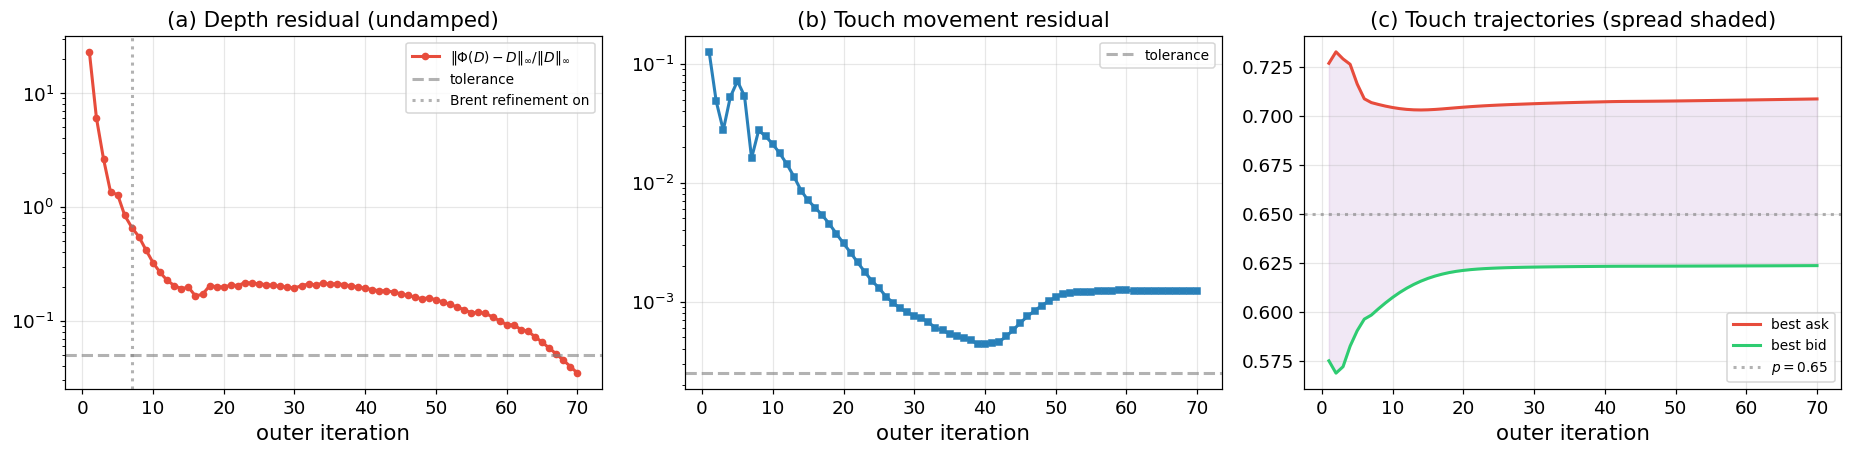

Converged: True (main), True (baseline)


In [13]:
h, h0 = out['hist'], out0['hist']
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))

ax = axes[0]
ax.semilogy(np.arange(1, len(h['resD'])+1), h['resD'], 'o-', ms=4,
            color='#e74c3c', label=r'$\|\Phi(D)-D\|_\infty/\|D\|_\infty$')
ax.axhline(tol_D, color='gray', ls='--', alpha=0.6, label='tolerance')
ax.axvline(7, color='gray', ls=':', alpha=0.6, label='Brent refinement on')
ax.set_xlabel('outer iteration'); ax.set_title('(a) Depth residual (undamped)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(np.arange(1, len(h['resT'])+1), h['resT'], 's-', ms=4,
            color='#2980b9')
ax.axhline(tol_touch, color='gray', ls='--', alpha=0.6, label='tolerance')
ax.set_xlabel('outer iteration'); ax.set_title('(b) Touch movement residual')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[2]
it_ax = np.arange(1, len(h['ask'])+1)
ax.plot(it_ax, h['ask'], '-', color='#e74c3c', label='best ask')
ax.plot(it_ax, h['bid'], '-', color='#2ecc71', label='best bid')
ax.fill_between(it_ax, h['bid'], h['ask'], alpha=0.12, color='#8e44ad')
ax.axhline(p_mid, color='gray', ls=':', alpha=0.6, label=f'$p={p_mid}$')
ax.set_xlabel('outer iteration'); ax.set_title('(c) Touch trajectories (spread shaded)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Converged: {out['converged']} (main), {out0['converged']} (baseline)")

## 11. LOB shape — densities, cumulative depth, endogenous spread

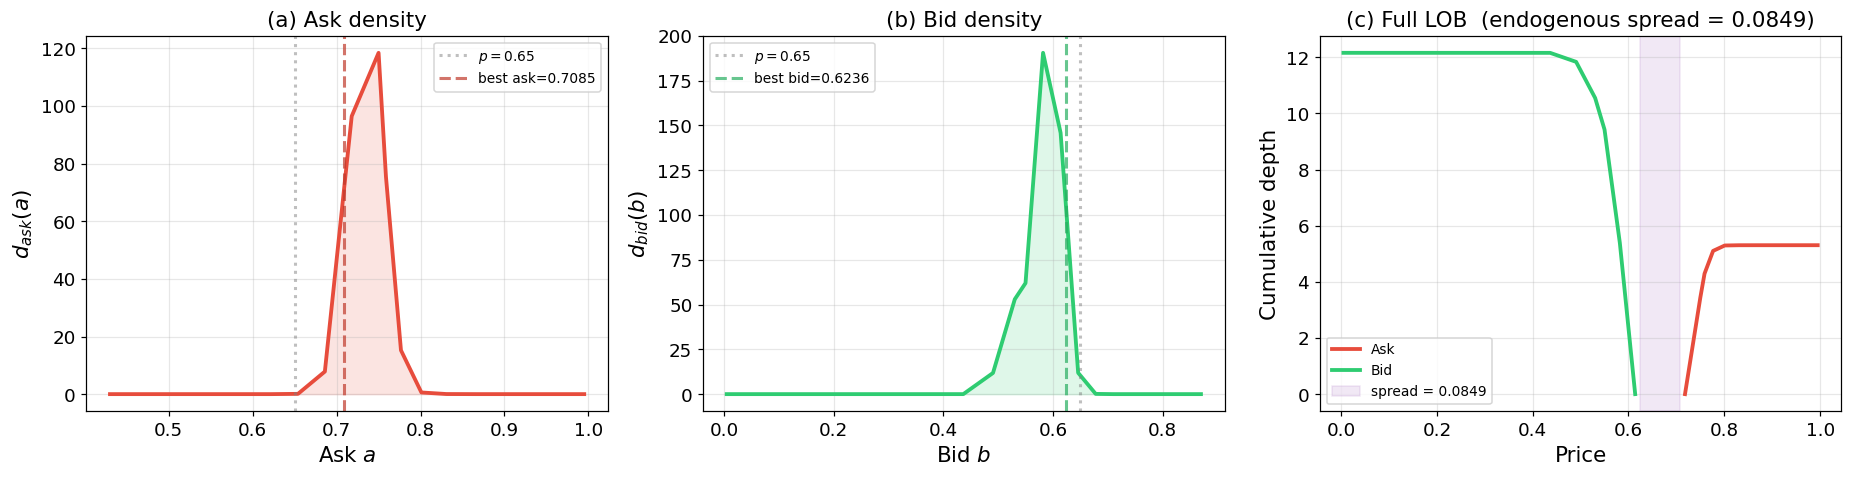

Total ask depth = 7.10,  total bid depth = 14.88


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

ax = axes[0]
ax.plot(gY, DY, color='#e74c3c', lw=2.5)
ax.fill_between(gY, 0, DY, alpha=0.15, color='#e74c3c')
ax.axvline(p_mid,  color='gray',    ls=':',  alpha=0.5, label=f'$p={p_mid}$')
ax.axvline(a_best, color='#c0392b', ls='--', alpha=0.7, label=f'best ask={a_best:.4f}')
ax.set_xlabel('Ask $a$'); ax.set_ylabel('$d_{ask}(a)$')
ax.set_title('(a) Ask density'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(b_grid, d_bid, color='#2ecc71', lw=2.5)
ax.fill_between(b_grid, 0, d_bid, alpha=0.15, color='#2ecc71')
ax.axvline(p_mid,  color='gray',    ls=':',  alpha=0.5, label=f'$p={p_mid}$')
ax.axvline(b_best, color='#27ae60', ls='--', alpha=0.7, label=f'best bid={b_best:.4f}')
ax.set_xlabel('Bid $b$'); ax.set_ylabel('$d_{bid}(b)$')
ax.set_title('(b) Bid density'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# cumulative depth from the touches outward
ask_mask = gY >= a_best - 1e-9
DC_ask = np.zeros_like(gY)
for i in range(len(gY)):
    if gY[i] > a_best:
        m_ = (gY >= a_best) & (gY <= gY[i])
        DC_ask[i] = np.trapz(DY[m_], gY[m_]) if m_.sum() > 1 else 0.0
DC_bid = np.zeros_like(b_grid)
for i in range(len(b_grid)):
    if b_grid[i] < b_best:
        m_ = (b_grid >= b_grid[i]) & (b_grid <= b_best)
        DC_bid[i] = np.trapz(d_bid[m_], b_grid[m_]) if m_.sum() > 1 else 0.0

ax = axes[2]
ax.plot(gY[ask_mask], DC_ask[ask_mask], color='#e74c3c', lw=2.5, label='Ask')
ax.plot(b_grid[b_grid <= b_best], DC_bid[b_grid <= b_best],
        color='#2ecc71', lw=2.5, label='Bid')
ax.axvspan(b_best, a_best, color='#8e44ad', alpha=0.12,
           label=f'spread = {spread:.4f}')
ax.set_xlabel('Price'); ax.set_ylabel('Cumulative depth')
ax.set_title(f'(c) Full LOB  (endogenous spread = {spread:.4f})')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Total ask depth = {np.trapz(DY, gY):.2f},  "
      f"total bid depth = {np.trapz(d_bid, b_grid):.2f}")

## 12. The spread mechanism — break-even frontier and adverse selection

The zero-profit ask $a_0(v)$ solves $a(1-f) = (1-\chi(a))v + \chi(a)$. The marginal LP
($v \downarrow b_{\text{best}}$) cannot profitably quote below $a_0(b_{\text{best}}) >
b_{\text{best}}$: this is what holds the touch off the bid.

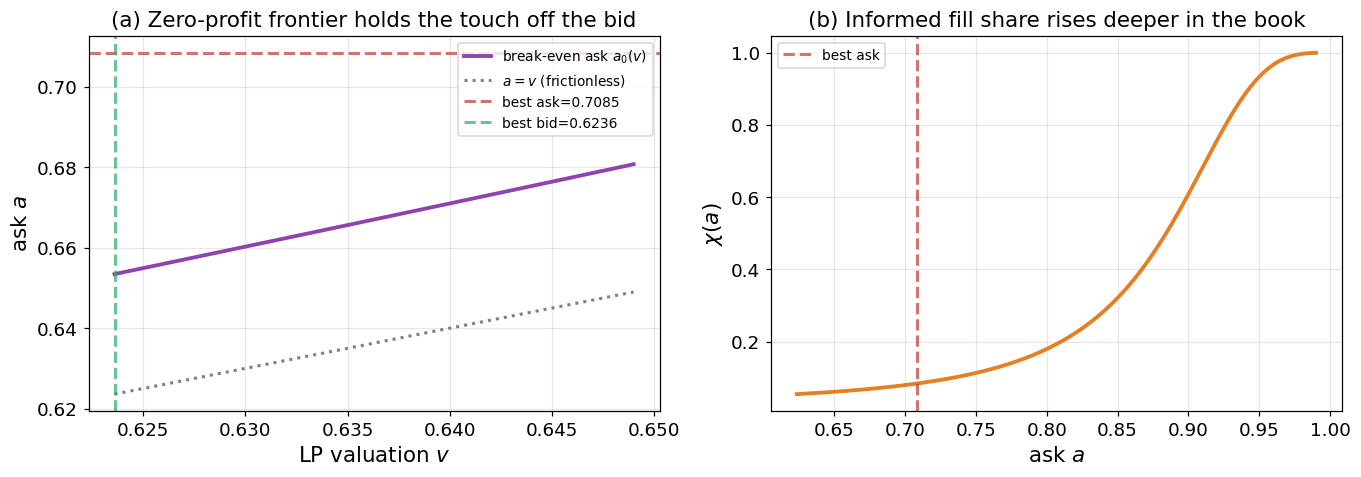

In [15]:
from scipy.optimize import brentq
F, Fi, chiY, phiY, m_effY = side_funcs(p_mid, alpha_F, beta_F)

def a_zero(v):
    g = lambda a: a * (1 - fee) - ((1 - chiY(a)) * v + chiY(a))
    aa = np.linspace(v + 1e-4, 0.995, 400)
    gv = np.array([g(a) for a in aa])
    pos = np.where(gv > 0)[0]
    if len(pos) == 0:
        return np.nan          # adverse selection too strong: no profitable ask
    i = pos[0]
    return aa[i] if i == 0 else brentq(g, aa[i - 1], aa[i])

vv = np.linspace(b_best, p_mid - 1e-3, 60)
az = np.array([a_zero(v) for v in vv])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
ax = axes[0]
ax.plot(vv, az, color='#8e44ad', lw=2.5, label=r'break-even ask $a_0(v)$')
ax.plot(vv, vv, color='gray', ls=':', label='$a = v$ (frictionless)')
ax.axhline(a_best, color='#c0392b', ls='--', alpha=0.7, label=f'best ask={a_best:.4f}')
ax.axvline(b_best, color='#27ae60', ls='--', alpha=0.7, label=f'best bid={b_best:.4f}')
ax.set_xlabel('LP valuation $v$'); ax.set_ylabel('ask $a$')
ax.set_title('(a) Zero-profit frontier holds the touch off the bid')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
aa = np.linspace(b_best, 0.99, 200)
ax.plot(aa, [chiY(a) for a in aa], color='#e67e22', lw=2.5)
ax.axvline(a_best, color='#c0392b', ls='--', alpha=0.7, label='best ask')
ax.set_xlabel('ask $a$'); ax.set_ylabel(r'$\chi(a)$')
ax.set_title('(b) Informed fill share rises deeper in the book')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 13. Fill rates, order flow

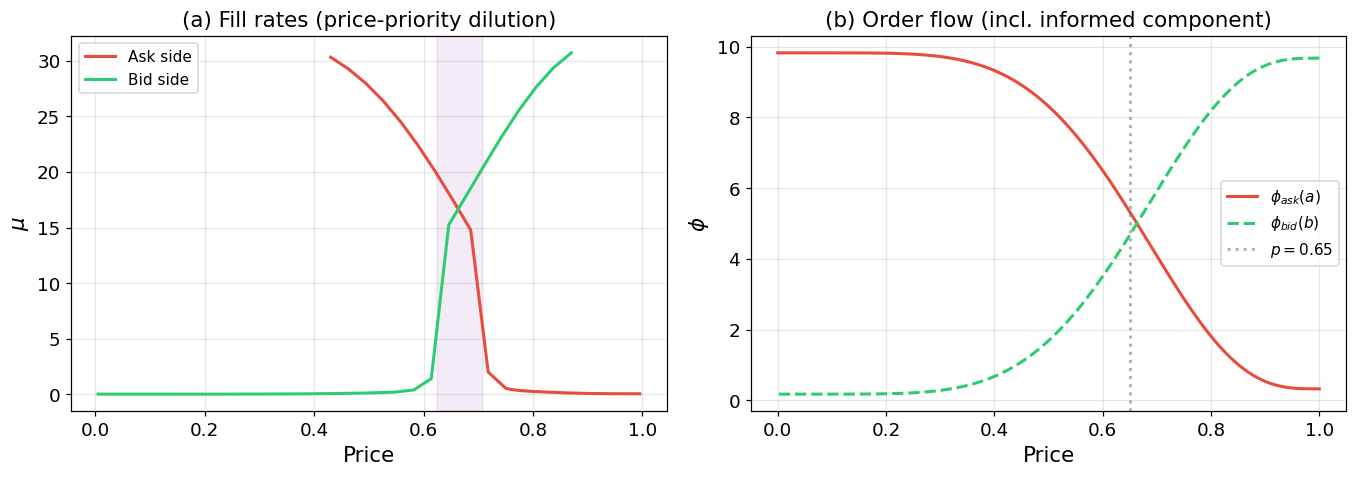

In [16]:
F_N, Fi_N, chiN, phiN, m_effN = side_funcs(1 - p_mid, beta_F, alpha_F)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

ax = axes[0]
ax.plot(gY, tabY['mu'], color='#e74c3c', lw=2, label='Ask side')
ax.plot(b_grid, tabN['mu'][::-1], color='#2ecc71', lw=2, label='Bid side')
ax.axvspan(b_best, a_best, color='#8e44ad', alpha=0.10)
ax.set_xlabel('Price'); ax.set_ylabel(r'$\mu$')
ax.set_title('(a) Fill rates (price-priority dilution)'); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
af = np.linspace(0, 1, 300)
ax.plot(af, phiY(af), color='#e74c3c', lw=2, label=r'$\phi_{ask}(a)$')
ax.plot(1 - af, phiN(af), color='#2ecc71', lw=2, ls='--', label=r'$\phi_{bid}(b)$')
ax.axvline(p_mid, color='gray', ls=':', alpha=0.6, label=f'$p={p_mid}$')
ax.set_xlabel('Price'); ax.set_ylabel(r'$\phi$')
ax.set_title('(b) Order flow (incl. informed component)')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 14. Bertrand sorting

Sorting by patience survives all fixes: for fixed $v$, $a^*(v,r)$ decreases in $r$
(impatient LPs trade margin for speed), and mean depth $\bar d$ declines in $r$.
Legends show **real LP valuations** on the classification-consistent windows
(bid-side values are $1 - v_{NO}$, i.e. true YES valuations, not solver-internal
mirrored ones).

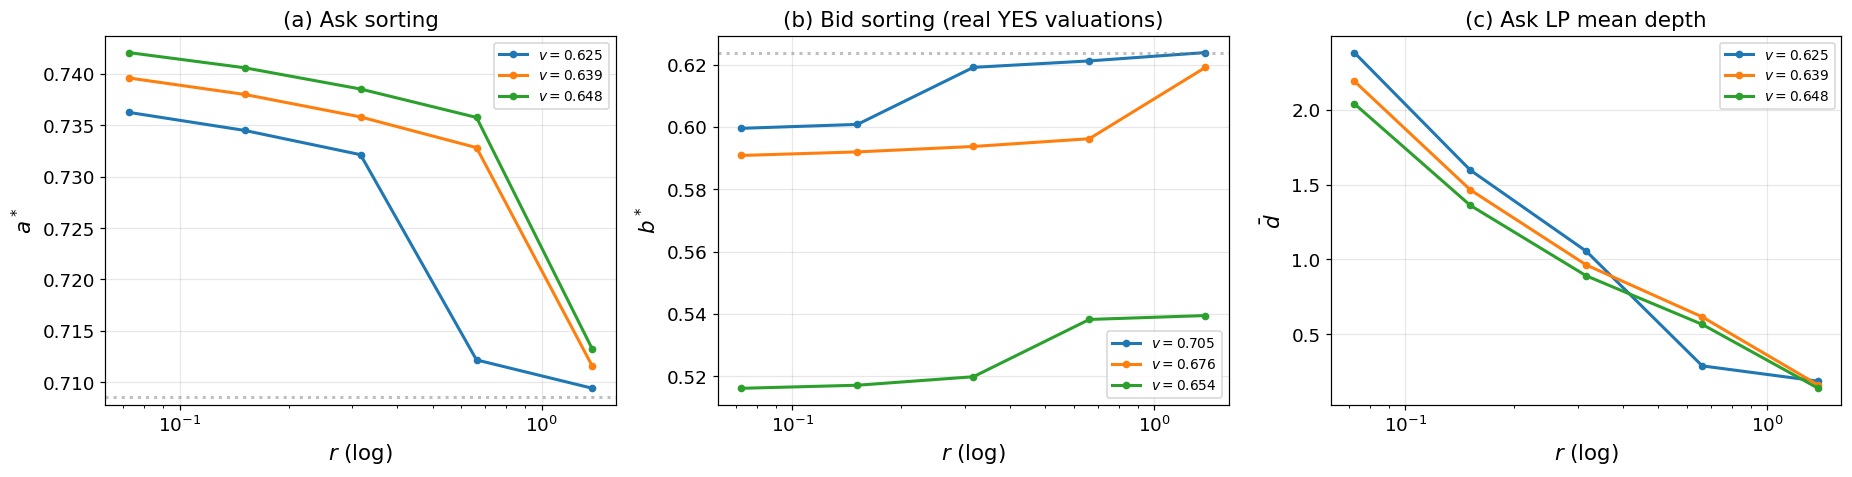

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
vY, vN = tabY['v_grid'], tabN['v_grid']

ax = axes[0]
for kv in [0, N_v // 2, N_v - 1]:
    ax.plot(r_grid, tabY['a_star'][kv, :], 'o-', ms=4, label=f'$v={vY[kv]:.3f}$')
ax.axhline(a_best, color='gray', ls=':', alpha=0.5)
ax.set_xscale('log'); ax.set_xlabel('$r$ (log)'); ax.set_ylabel('$a^*$')
ax.set_title('(a) Ask sorting'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
for kv in [0, N_v // 2, N_v - 1]:
    ax.plot(r_grid, 1 - tabN['a_star'][kv, :], 'o-', ms=4,
            label=f'$v={1 - vN[kv]:.3f}$')
ax.axhline(b_best, color='gray', ls=':', alpha=0.5)
ax.set_xscale('log'); ax.set_xlabel('$r$ (log)'); ax.set_ylabel('$b^*$')
ax.set_title('(b) Bid sorting (real YES valuations)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[2]
for kv in [0, N_v // 2, N_v - 1]:
    ax.plot(r_grid, tabY['d_bar'][kv, :], 'o-', ms=4, label=f'$v={vY[kv]:.3f}$')
ax.set_xscale('log'); ax.set_xlabel('$r$ (log)'); ax.set_ylabel(r'$\bar d$')
ax.set_title('(c) Ask LP mean depth'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 15. Final summary

In [18]:
print("=" * 64)
print("EQUILIBRIUM SUMMARY  (eta=0.05, f=0.01)")
print("=" * 64)
print(f"Best ask                 = {a_best:.4f}")
print(f"Best bid                 = {b_best:.4f}")
print(f"Endogenous spread        = {spread:.4f}")
print(f"Emergent mid             = {(a_best + b_best) / 2:.4f}  (fundamental p = {p_mid})")
print(f"Total ask / bid depth    = {np.trapz(DY, gY):.2f} / {np.trapz(d_bid, b_grid):.2f}")
print(f"Ask LP window            = ({b_best:.3f}, {p_mid:.3f})   [classification-consistent]")
print(f"Bid LP window            = ({p_mid:.3f}, {a_best:.3f})")
nact = int(tabY['active'].sum()); ntot = tabY['active'].size
print(f"Active ask types         = {nact}/{ntot}  (exits = adverse-selection shutdown)")
print(f"Converged (residual)     = {out['converged']}   — no Cesaro averaging used")
print(f"Spread decomposition     : capacity/impatience rent = {a0 - b0:.4f}")
print(f"                           fee + adverse-selection  = {spread - (a0 - b0):.4f}")

EQUILIBRIUM SUMMARY  (eta=0.05, f=0.01)
Best ask                 = 0.7085
Best bid                 = 0.6236
Endogenous spread        = 0.0849
Emergent mid             = 0.6661  (fundamental p = 0.65)
Total ask / bid depth    = 7.10 / 14.88
Ask LP window            = (0.624, 0.650)   [classification-consistent]
Bid LP window            = (0.650, 0.709)
Active ask types         = 40/40  (exits = adverse-selection shutdown)
Converged (residual)     = True   — no Cesaro averaging used
Spread decomposition     : capacity/impatience rent = 0.0561
                           fee + adverse-selection  = 0.0289


## 16. Optional: spread comparative statics in $\eta$

Set `RUN_COMPARATIVE = True` to map the spread as a function of the informed share
(several extra full equilibrium solves; ~5 min each on one core).

[eta=0.0] CONVERGED at iteration 34 (resD=0.0333 < 0.05, moveT=0.00006 < 0.00025, 3 consecutive passes)
eta=0.000  spread=0.0581
[eta=0.025] WARNING: tolerance not reached in 35 iterations (final resD=0.2075, moveT=0.00030) — reported honestly, no averaging applied.
eta=0.025  spread=0.0779
[eta=0.05] WARNING: tolerance not reached in 35 iterations (final resD=0.2103, moveT=0.00013) — reported honestly, no averaging applied.
eta=0.050  spread=0.0836
[eta=0.1] CONVERGED at iteration 23 (resD=0.0276 < 0.05, moveT=0.00008 < 0.00025, 3 consecutive passes)
eta=0.100  spread=0.1157


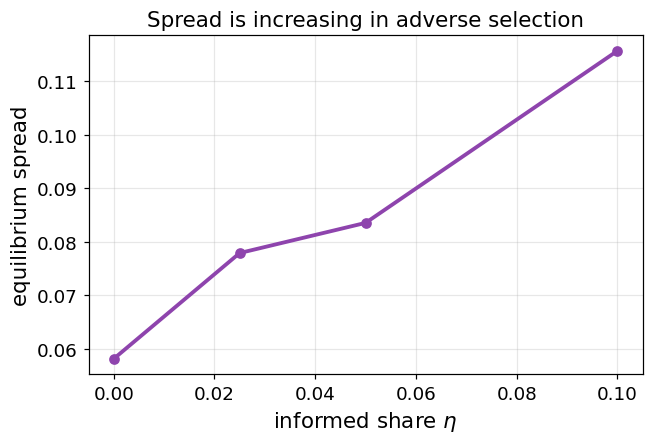

In [21]:
RUN_COMPARATIVE = True
if RUN_COMPARATIVE:
    etas = [0.0, 0.025, 0.05, 0.10]
    spreads = []
    for e in etas:
        o = run_equilibrium(e, 0.01, f"eta={e}", outer=35, verbose=False)
        spreads.append(o['aY'] + o['aN'] - 1.0)
        print(f"eta={e:.3f}  spread={spreads[-1]:.4f}")
    plt.figure(figsize=(6.5, 4))
    plt.plot(etas, spreads, 'o-', color='#8e44ad', lw=2.5)
    plt.xlabel(r'informed share $\eta$'); plt.ylabel('equilibrium spread')
    plt.title('Spread is increasing in adverse selection'); plt.grid(True, alpha=0.3)
    plt.show()